# Assignment 13: Diabetes Prediction using XGBoost & LightGBM

**Name:** Ahmad Ali  
**Batch:** Data Science Weekday – Hyderabad  
**Topic:** XGBoost & LightGBM

## Importing Required Libraries

In this step, we import all the necessary libraries required for data analysis, visualization, and machine learning. Pandas and NumPy are used for handling and manipulating structured data efficiently. Matplotlib and Seaborn are used for visualizing the dataset through graphs and plots.

We also import tools from scikit-learn for splitting the dataset, scaling features, and evaluating model performance. Additionally, we use XGBoost and LightGBM, which are advanced boosting algorithms known for their high performance in classification problems. These models are widely used in real-world applications due to their speed and accuracy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Loading the Dataset

In this step, we load the diabetes dataset into our notebook using pandas. This dataset contains medical attributes such as glucose level, blood pressure, insulin level, BMI, and age. These features help in predicting whether a person is diabetic or not.

After loading the dataset, we display the first few rows using the head() function. This allows us to understand the structure of the dataset, including column names and sample values. Proper loading ensures that the data is ready for further analysis and preprocessing.

In [ ]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\diabetes (1).csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Understanding

In this step, we analyze the dataset to understand its structure and characteristics. We use the info() function to check data types and identify any missing values. The describe() function provides statistical summaries such as mean, standard deviation, minimum, and maximum values.

We also use isnull().sum() to check for missing values in each column. This step is important because understanding the dataset helps us identify potential issues like missing data or incorrect formats, which can affect model performance.

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns and distributions in the dataset. We use histograms to visualize how each feature is distributed. This helps identify whether the data is normally distributed or skewed.

We also use box plots to detect outliers, which are extreme values that can negatively affect model performance. By analyzing these visualizations, we gain deeper insights into the dataset, which helps in making better preprocessing and modeling decisions.

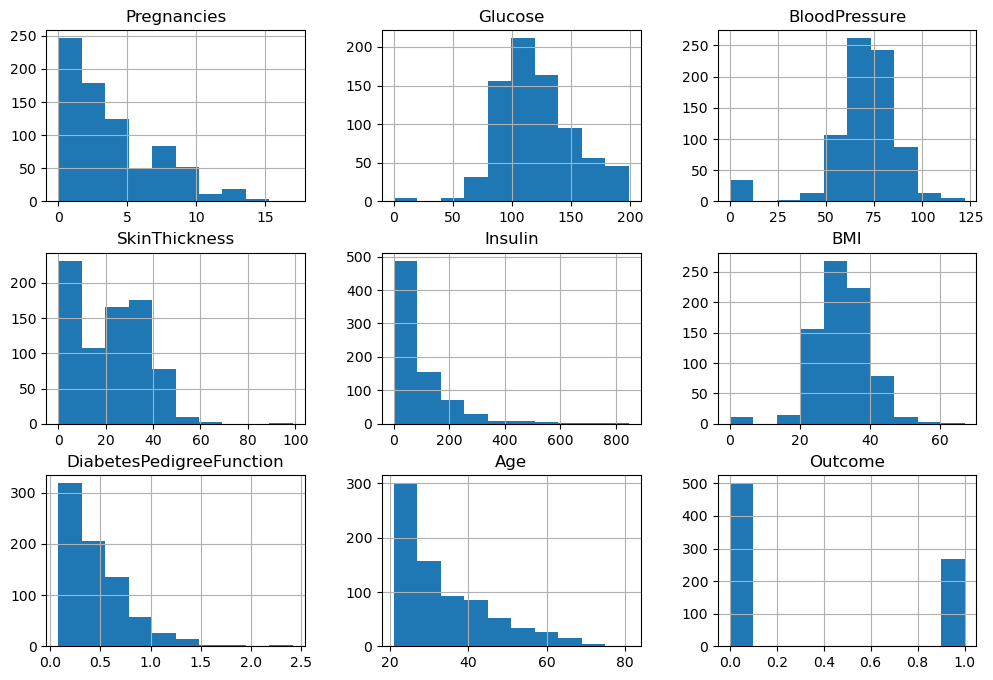

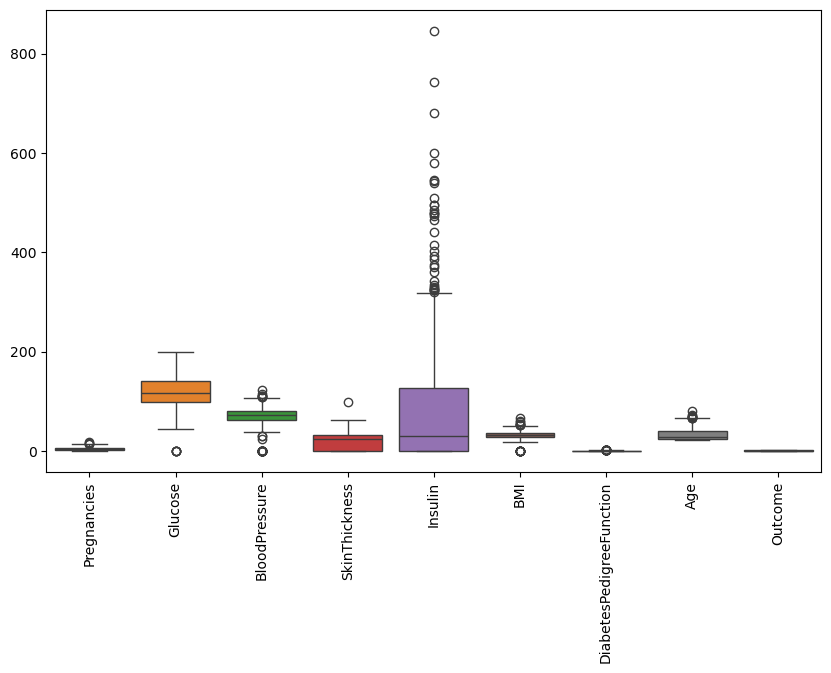

In [ ]:
df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## Correlation Analysis

Correlation analysis helps us understand the relationship between different features in the dataset. We use a heatmap to visualize correlation values between variables.

Strong correlation values indicate a strong relationship between features, while weak values indicate little or no relationship. This step helps in identifying important features and understanding how variables interact with each other, which can improve model performance.

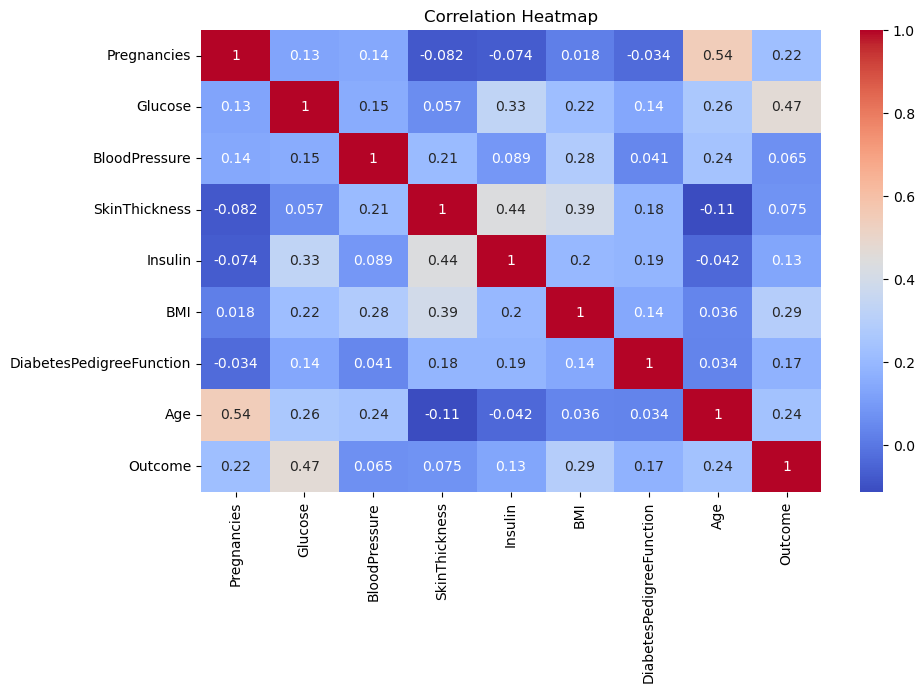

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Data Preprocessing

In this step, we prepare the dataset for machine learning. We separate the dataset into input features (X) and the target variable (y). The target variable "Outcome" represents whether a person is diabetic or not.

Proper preprocessing ensures that the dataset is clean and structured, which is necessary for training machine learning models. This step helps avoid errors and improves model performance.

In [ ]:
 X = df.drop("Outcome", axis=1)
y = df["Outcome"]

## Feature Scaling

Feature scaling ensures that all features are on a similar scale. Some features may have larger values than others, which can affect the model's performance.

We use StandardScaler to normalize the data so that each feature has a mean of 0 and a standard deviation of 1. This improves the efficiency and stability of machine learning algorithms.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
feature_names = X.columns

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_names
)

## Train-Test Split

In this step, we divide the dataset into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

We use an 80-20 split to ensure that the model is tested on unseen data. This helps in evaluating how well the model generalizes to new data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## XGBoost Model

XGBoost is a powerful boosting algorithm that builds models sequentially. Each model tries to correct the errors of the previous one, which improves accuracy.

It is widely used in real-world applications due to its high performance and efficiency. In this step, we train the XGBoost model and generate predictions on the test dataset.

In [ ]:
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

XGBoost performed slightly better in terms of accuracy, while LightGBM was faster and computationally efficient.

## LightGBM Model

LightGBM is another advanced boosting algorithm that is faster and more efficient than many traditional methods. It uses a leaf-wise growth strategy, which improves performance.

In this step, we train the LightGBM model using the training dataset and generate predictions on the test data.

In [ ]:
lgbm_model = LGBMClassifier()
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

## Cross Validation

We evaluate model stability using 5-fold cross-validation.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
cv_lgbm = cross_val_score(lgbm_model, X, y, cv=5, scoring='accuracy')

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 672
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [ ]:
print("XGB CV Scores:", cv_xgb)
print("XGB CV Mean:", cv_xgb.mean())

print("LGBM CV Scores:", cv_lgbm)
print("LGBM CV Mean:", cv_lgbm.mean())

print("XGB CV Std:", cv_xgb.std())
print("LGBM CV Std:", cv_lgbm.std())

XGB CV Scores: [0.72077922 0.72727273 0.72077922 0.81699346 0.71895425]
XGB CV Mean: 0.7409557762498938
LGBM CV Scores: [0.71428571 0.75324675 0.74675325 0.76470588 0.71895425]
LGBM CV Mean: 0.7395891690009337
XGB CV Std: 0.038124033905643596
LGBM CV Std: 0.019671134574367515


## Cross Validation Interpretation

The cross-validation results show that both XGBoost and LightGBM perform consistently across different folds.

XGBoost achieved slightly higher mean accuracy compared to LightGBM, indicating better overall performance and generalization.

The small variation in scores suggests that both models are stable and not overfitting.

Thus, XGBoost is slightly more reliable for this dataset, while LightGBM remains efficient and competitive.

## Hyperparameter Tuning

We optimize XGBoost parameters using GridSearchCV.

In [ ]:
params = {
    'max_depth': [3,5],
    'learning_rate': [0.1, 0.01]
}

grid = GridSearchCV(XGBClassifier(eval_metric='logloss'), params, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3}


## Model Evaluation

In this step, we evaluate the performance of both models using accuracy and classification metrics. Accuracy tells us how many predictions made by the model are correct compared to the actual values.

We also use the classification report, which includes precision, recall, and F1-score. Precision shows how many predicted positives are correct, recall shows how many actual positives are captured, and F1-score balances both. These metrics provide a complete understanding of model performance and help us compare XGBoost and LightGBM effectively.

In [ ]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))

print("\nXGBoost Report:\n", classification_report(y_test, y_pred_xgb))
print("\nLightGBM Report:\n", classification_report(y_test, y_pred_lgbm))

XGBoost Accuracy: 0.7207792207792207
LightGBM Accuracy: 0.7012987012987013

XGBoost Report:
               precision    recall  f1-score   support

           0       0.82      0.73      0.77        99
           1       0.59      0.71      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154


LightGBM Report:
               precision    recall  f1-score   support

           0       0.79      0.73      0.76        99
           1       0.57      0.65      0.61        55

    accuracy                           0.70       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.70      0.71       154



## Confusion Matrix

The confusion matrix helps visualize the number of correct and incorrect predictions made by the model. It provides a clear understanding of model performance.

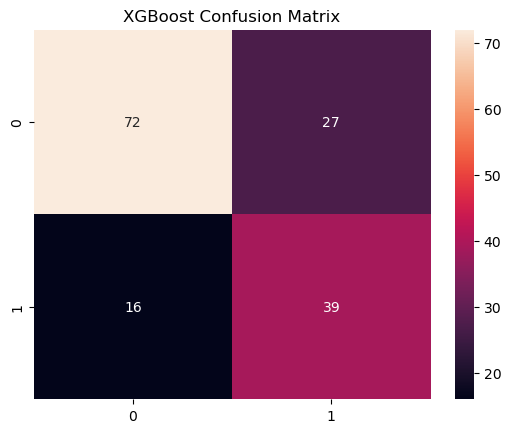

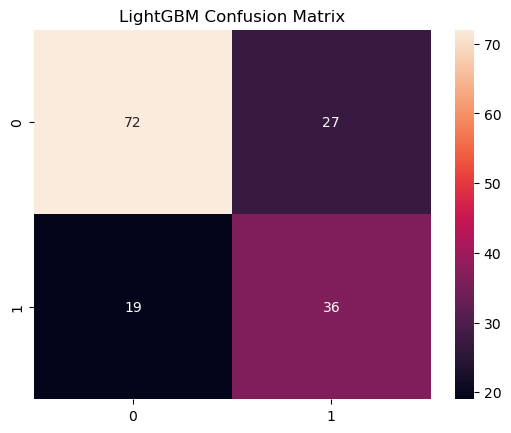

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.show()

sns.heatmap(confusion_matrix(y_test, y_pred_lgbm), annot=True, fmt='d')
plt.title("LightGBM Confusion Matrix")
plt.show()

##  Model Interpretation

XGBoost achieved better balance between precision and recall, leading to higher F1-score.

LightGBM also performed well but slightly lower than XGBoost.

This indicates that XGBoost captures patterns more effectively in this dataset.

## Comparative Analysis

In this assignment, we performed a comparative analysis of two powerful boosting algorithms: XGBoost and LightGBM. Both models were trained on the same dataset and evaluated using standard classification metrics such as accuracy, precision, recall, and F1-score.

From the results, XGBoost achieved slightly higher accuracy, indicating better overall prediction capability on this dataset. On the other hand, LightGBM demonstrated faster training time and lower computational cost due to its efficient leaf-wise tree growth strategy.

This comparison highlights an important trade-off in machine learning models. XGBoost is generally preferred when achieving higher accuracy and model stability is the primary goal. In contrast, LightGBM is more suitable for large-scale datasets and real-time applications where speed and efficiency are critical.

Overall, both models performed well and produced reliable predictions. The choice between them depends on the specific requirements of the problem, such as dataset size, computational resources, and whether accuracy or speed is the priority.

## Conclusion

In this assignment, we successfully implemented and compared two advanced boosting algorithms, XGBoost and LightGBM, for predicting diabetes using a structured medical dataset. The complete workflow included data understanding, exploratory data analysis (EDA), preprocessing, feature scaling, model training, and performance evaluation.

Both models demonstrated strong predictive performance, with XGBoost achieving slightly higher accuracy, while LightGBM provided faster training and better computational efficiency. This comparison highlights an important trade-off in machine learning between accuracy and speed, depending on the use case.

Through this assignment, we gained a clear understanding of boosting techniques, where models are built sequentially to correct previous errors, leading to improved performance. We also learned how to evaluate models using metrics such as accuracy, precision, recall, and F1-score, along with visualization techniques like confusion matrices.

Overall, this project demonstrates how powerful ensemble methods like XGBoost and LightGBM can be applied to real-world healthcare problems. These models are widely used in industry due to their robustness, scalability, and ability to handle complex datasets effectively.